# Notebook 06 — Tracking con KymoButler sobre quimógrafos sintéticos (ingenia)

Primer **baseline de tracking** sobre los quimógrafos sintéticos generados por `synthkymo` en el notebook 05. Usamos **KymoButler** (Jakobs, Franze & Bhatt, *eLife* 2019).

## Diferencias respecto a la versión anterior (generador simple)

1. **Formato de entrada**: quimógrafo `.tif` (uint8) + `positions.csv` con `pos_um` — ya no un PNG simple con `x_px`.
2. **Conversión de GT**: `pos_um` → columna de quimógrafo con el flip de soma: `col = kymo_width - 1 - pos_um / pixel_scale`.
3. **Dirección en quimógrafo (convención flipped)**:
   - `anterograde` (pos_um creciente) → estela hacia la **izquierda** (col decreciente) → dirección predicha **-1**.
   - `retrograde` (pos_um decreciente) → estela hacia la **derecha** (col creciente) → dirección predicha **+1**.
4. **Posible redimensionado de KymoButler**: si el ancho del quimógrafo no es múltiplo de 16, KymoButler puede redimensionar internamente. Se detecta comparando `raw.shape` con el TIFF nativo y se aplica un factor de escala a las coordenadas de los tracks antes de compararlos con el GT.

## Flujo

`kymograph.tif` (NB05) → PNG → KymoButler → scale_factor → comparación contra GT (`positions.csv`).

---

## 0. Prerrequisitos

```bash
uv sync                   # instala kymobutler + synthkymo
cd ../KymoButler && git lfs pull  # baja pesos ONNX
```


---

## 1. Setup


In [ ]:
import sys, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from PIL import Image

sys.path.append(str(Path("..") / "src"))
from axonal_tracking.parametros import PIXEL_SIZE_UM

try:
    import kymobutler
except ImportError as exc:
    raise ImportError(
        "No se pudo importar kymobutler. Corre 'uv sync' en el repo."
    ) from exc

KYMOBUTLER_DIR = Path(kymobutler.__file__).resolve().parents[2]
MODELOS_DIR = KYMOBUTLER_DIR / "models"

# Dataset generado por NB05
DIR_INGENIA = Path("..") / "data" / "sinteticos" / "ingenia"
assert (
    DIR_INGENIA.exists()
), f"Directorio no encontrado: {DIR_INGENIA}. Corre primero el notebook 05."

# Verificar pesos
pesos_pointer = [
    f
    for f in ("bidirectional_seg.onnx", "decision_module.onnx")
    if not (MODELOS_DIR / f).exists() or (MODELOS_DIR / f).stat().st_size < 1024
]
assert not pesos_pointer, (
    f"Pesos faltantes o como puntero LFS: {pesos_pointer}. "
    f"Corre en {KYMOBUTLER_DIR}: git lfs pull"
)

DEVICE = "cpu"
PIXEL_SCALE = PIXEL_SIZE_UM  # µm/px

print(f"KymoButler   : {KYMOBUTLER_DIR}")
print(f"Dataset      : {DIR_INGENIA.resolve()}")
print(f"pixel_scale  : {PIXEL_SCALE} µm/px")
print("Setup OK.")

---

## 2. Cargar modelos


In [2]:
from kymobutler.models.weights import load_default_models

models = load_default_models(model_dir=MODELOS_DIR, device=DEVICE)
print("Modelos cargados:", list(models.keys()))

Modelos cargados: ['binet', 'uninet', 'decnet', 'classnet']


### Smoke test (bitest.png de KymoButler)


In [ ]:
from kymobutler.segmentation import segment_bidirectional
from kymobutler.tracking import track_bidirectional

_bitest = KYMOBUTLER_DIR / "tests" / "data" / "bitest.png"
if _bitest.exists():
    _wn, _raw, _pre, _pred = segment_bidirectional(
        str(_bitest), models["binet"], device=DEVICE
    )
    _tracks = track_bidirectional(
        _pred,
        _pre,
        _wn,
        vision_net=models["decnet"],
        threshold=0.2,
        min_size=10,
        min_frames=10,
        device=DEVICE,
    )
    print(f"Smoke test bitest.png: {len(_tracks)} tracks (esperado ~13)")
else:
    print("bitest.png no encontrado, salteo smoke test.")

/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]
                                                                

Smoke test bitest.png: 13 tracks (esperado ~13)


---

## 3. Selección de sample

Procesamos la **primera muestra** del dataset (`sample_00000`). Al final del notebook se muestra cómo iterar sobre todos los samples para métricas agregadas.


In [4]:
df_manifest = pd.read_csv(DIR_INGENIA / "manifest.csv")
print(df_manifest.to_string(index=False))

SAMPLE = df_manifest.iloc[0]["sample_dir"]  # sample_00000
SAMPLE_DIR = DIR_INGENIA / SAMPLE

KYMO_TIF = SAMPLE_DIR / "kymograph.tif"
KYMO_PNG = SAMPLE_DIR / "kymograph.png"
POS_CSV = SAMPLE_DIR / "positions.csv"
META_JSON = SAMPLE_DIR / "metadata.json"

# Convertir TIFF a PNG si hace falta (bit_depth=8, así que ya es uint8)
if not KYMO_PNG.exists():
    kymo_arr = tifffile.imread(KYMO_TIF)
    Image.fromarray(kymo_arr, mode="L").save(KYMO_PNG)

kymo_native = tifffile.imread(KYMO_TIF)
meta = json.loads(META_JSON.read_text())

kymo_native_h, kymo_native_w = kymo_native.shape
print(f"\nSample      : {SAMPLE}")
print(f"kymo nativo : {kymo_native_h} × {kymo_native_w} px  (frames × pos_axon)")
print(f"kymo_w / 16 : {kymo_native_w / 16:.2f}")
print(f"Metadata    : {meta}")

 index   sample_dir  seed  n_particles  axon_length_um  movie_width  movie_height  n_frames  kymograph_width nucleus_position
     0 sample_00000  1000           15       32.133780          512           128       256              300              top
     1 sample_00001  1001           15       51.445414          512           128       256              481            right
     2 sample_00002  1002           15       45.706374          512           128       256              427             left
     3 sample_00003  1003           15       43.319755          512           128       256              405           bottom
     4 sample_00004  1004           15       65.505111          512           128       256              612             left
     5 sample_00005  1005           15       41.109291          512           128       256              384           bottom
     6 sample_00006  1006           15       57.812270          512           128       256              540          

---

## 4. Segmentación con KymoButler

Después de `segment_bidirectional` comparamos `raw.shape` con el tamaño nativo para detectar si KymoButler redimensionó. Si hay diferencia, calculamos `scale_factor` para traducir coordenadas de track ↔ GT.


/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]


was_negated  = False  (False = fondo oscuro, correcto para quimógrafo con tubo brillante)
raw.shape    = (256, 300)
kymo nativo  = (256, 300)
scale_factor = 1.0000  (sin redimensionado)


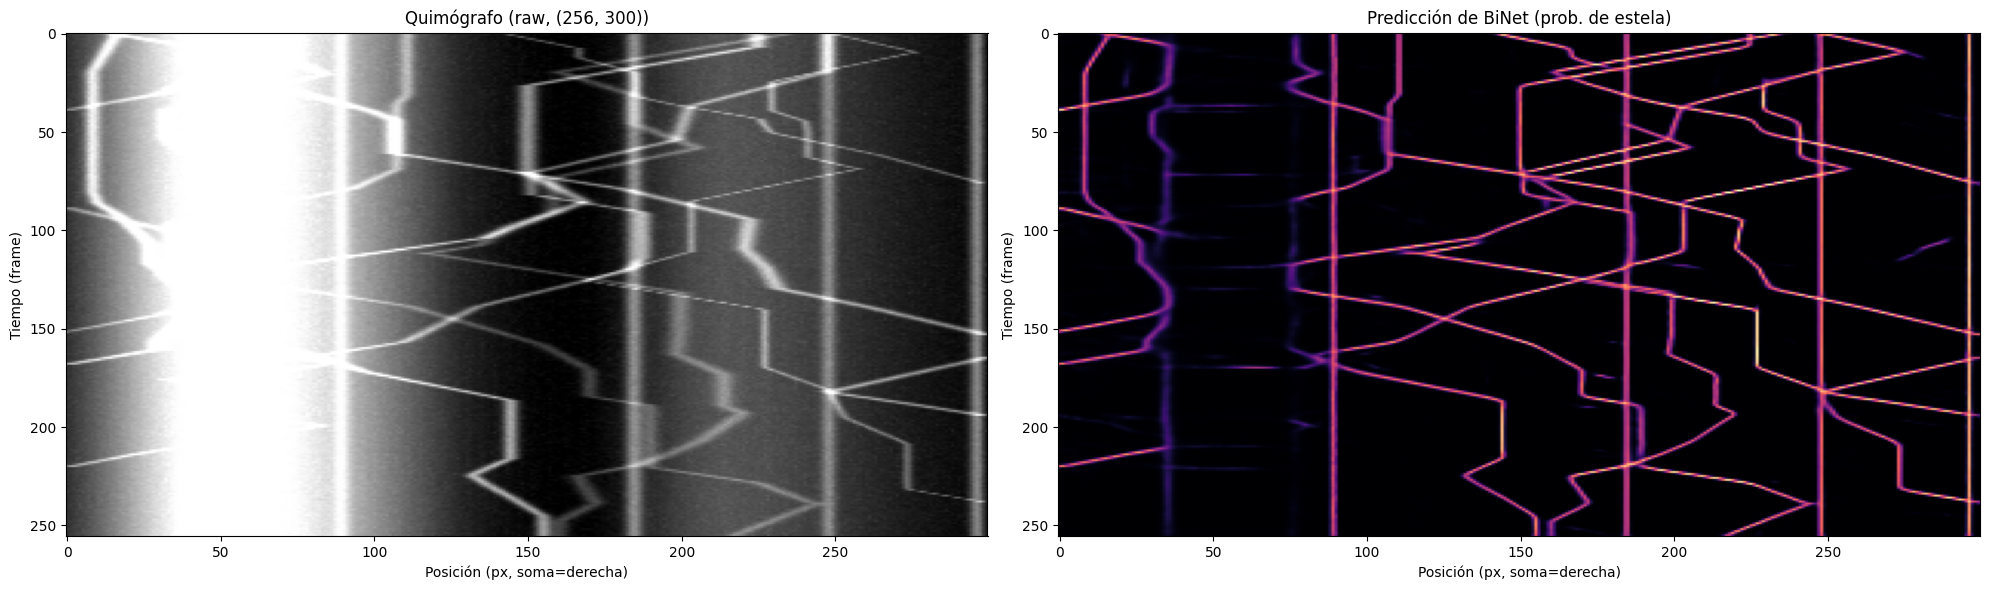

In [ ]:
was_negated, raw, preprocessed, prediction = segment_bidirectional(
    str(KYMO_PNG), models["binet"], device=DEVICE
)

kb_h, kb_w = raw.shape
scale_factor = kb_w / kymo_native_w  # >1 si KymoButler agrandó, <1 si achicó

print(
    f"was_negated  = {was_negated}  (False = fondo oscuro, correcto para quimógrafo con tubo brillante)"
)
print(f"raw.shape    = {raw.shape}")
print(f"kymo nativo  = {kymo_native.shape}")
print(
    f"scale_factor = {scale_factor:.4f}  ({'sin redimensionado' if abs(scale_factor-1)<0.01 else '⚠ KymoButler redimensionó — se aplica escala'})",
)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
axes[0].imshow(raw, cmap="gray", aspect="auto")
axes[0].set_title(f"Quimógrafo (raw, {raw.shape})")
axes[1].imshow(prediction, cmap="magma", aspect="auto")
axes[1].set_title("Predicción de BiNet (prob. de estela)")
for ax in axes:
    ax.set_xlabel("Posición (px, soma=derecha)")
    ax.set_ylabel("Tiempo (frame)")
plt.tight_layout()
plt.show()

---

## 5. Tracking


In [ ]:
tracks = track_bidirectional(
    prediction,
    preprocessed,
    was_negated,
    vision_net=models["decnet"],
    threshold=0.2,
    min_size=10,
    min_frames=10,
    device=DEVICE,
)
print(f"Tracks detectados: {len(tracks)}")
if tracks:
    largos = [len(t.points) for t in tracks]
    print(
        f"  Puntos/track: min={min(largos)}, mediana={int(np.median(largos))}, max={max(largos)}"
    )

Tracks detectados: 22
  Puntos/track: min=13, mediana=76, max=249


### Overlay de tracks

Convención de colores **según dirección en el quimógrafo** (flip: soma=derecha):

- **Magenta** = columna decrece → anterógrado (se aleja del soma).
- **Cyan** = columna crece → retrógrado (se acerca al soma).
- **Amarillo** = sin desplazamiento neto.


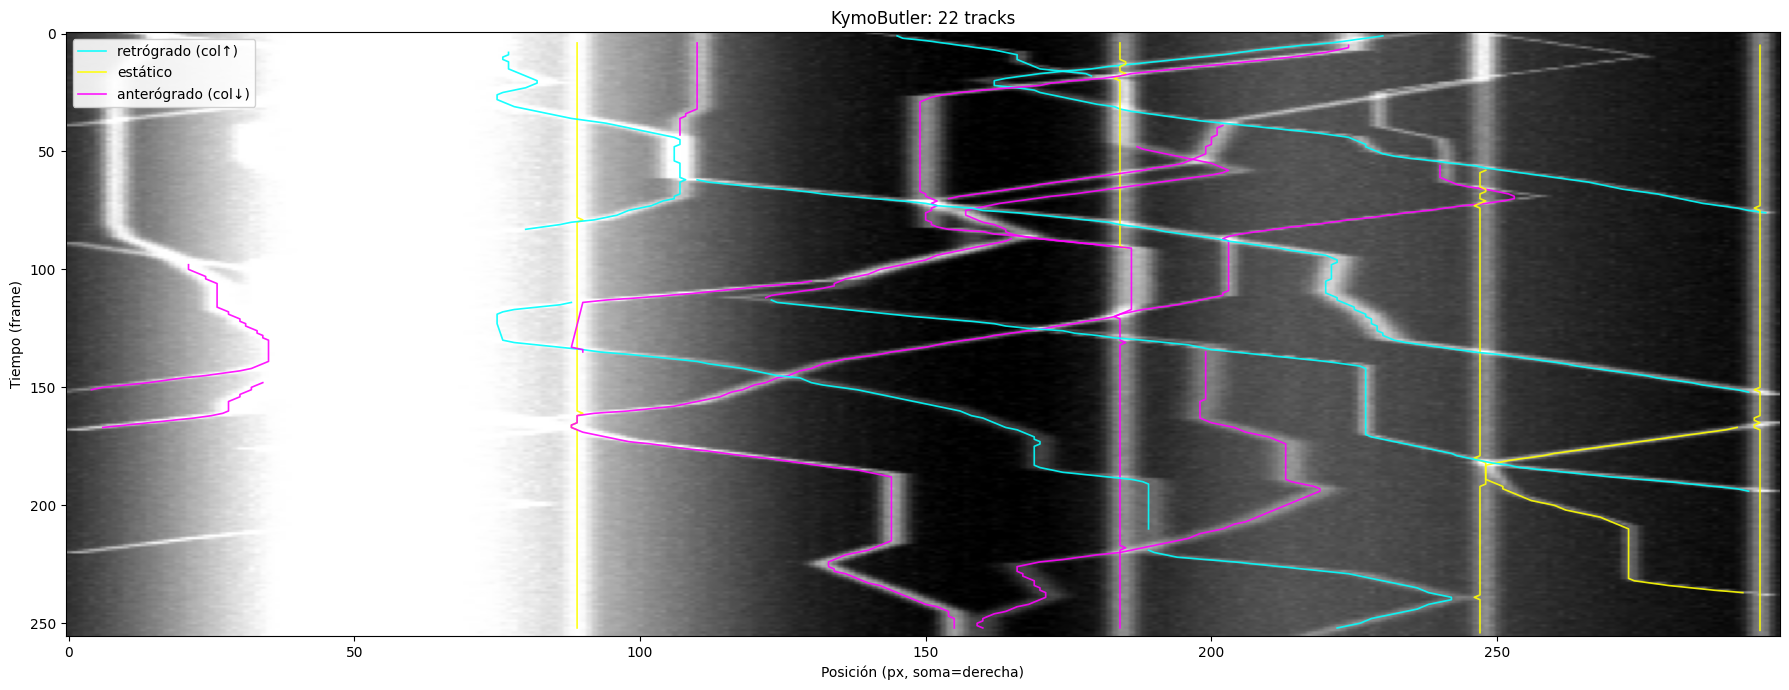

In [ ]:
def dir_track(trk):
    """Dirección por desplazamiento neto de columna: -1 izq (ant), +1 der (ret), 0 static."""
    d = trk.points[-1][1] - trk.points[0][1]
    if d > 1:
        return 1  # right / retrograde
    if d < -1:
        return -1  # left / anterograde
    return 0


DIR_COLOR = {-1: "magenta", 1: "cyan", 0: "yellow"}
DIR_LABEL = {-1: "anterógrado (col↓)", 1: "retrógrado (col↑)", 0: "estático"}

fig, ax = plt.subplots(figsize=(18, 7))
ax.imshow(raw, cmap="gray", aspect="auto")
vistos = set()
for trk in tracks:
    d = dir_track(trk)
    pts = np.array(trk.points)  # (N, 2) = (frame, col)
    lbl = DIR_LABEL[d] if d not in vistos else None
    vistos.add(d)
    ax.plot(
        pts[:, 1], pts[:, 0], color=DIR_COLOR[d], linewidth=1.2, alpha=0.9, label=lbl
    )
ax.set_title(f"KymoButler: {len(tracks)} tracks")
ax.set_xlabel("Posición (px, soma=derecha)")
ax.set_ylabel("Tiempo (frame)")
ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

---

## 6. Conversión del ground truth a coordenadas de quimógrafo

`pos_um` (longitud de arco desde el soma) → columna del quimógrafo con el flip:

```
kymo_col = (kymo_w_native - 1 - pos_um / pixel_scale) * scale_factor
```

Dirección GT en el quimógrafo (flipped, soma=derecha):

- `anterograde` → -1 (columna decreciente con el tiempo)
- `retrograde` → +1 (columna creciente)
- `static` → 0


In [ ]:
positions = pd.read_csv(POS_CSV)
# Solo filas visibles (pos_um dentro de los límites del axón)
pos_vis = positions[positions.visible == 1].copy()

# Conversión: pos_um → columna del quimógrafo escalada al espacio de KymoButler
pos_vis["kymo_col"] = (
    kymo_native_w - 1 - pos_vis["pos_um"] / PIXEL_SCALE
) * scale_factor

# Dirección GT en el quimógrafo (flipped)
GT_DIR = {"anterograde": -1, "retrograde": 1, "static": 0}

tipo_de = dict(pos_vis.drop_duplicates("particle_id").set_index("particle_id")["type"])
gt_ids = sorted(tipo_de.keys())
gt_dir = {pid: GT_DIR[tipo_de[pid]] for pid in gt_ids}

# Lookup rápido (pid, frame) → kymo_col
gt_col = {
    (int(r.particle_id), int(r.frame)): float(r.kymo_col)
    for r in pos_vis.itertuples(index=False)
}
gt_por_frame = {
    int(f): list(zip(sub.particle_id, sub.kymo_col))
    for f, sub in pos_vis.groupby("frame")
}

print(f"Partículas GT: {len(gt_ids)} ({dict(Counter(tipo_de.values()))})")
print(f"Filas en GT (visibles): {len(pos_vis)}")
print(
    f"Rango kymo_col en GT: [{pos_vis.kymo_col.min():.1f}, {pos_vis.kymo_col.max():.1f}]"
)
print(f"Rango columnas en KymoButler raw: [0, {kb_w-1}]")

Partículas GT: 15 ({'anterograde': 5, 'static': 5, 'retrograde': 5})
Filas en GT (visibles): 3298
Rango kymo_col en GT: [-1.2, 298.6]
Rango columnas en KymoButler raw: [0, 299]


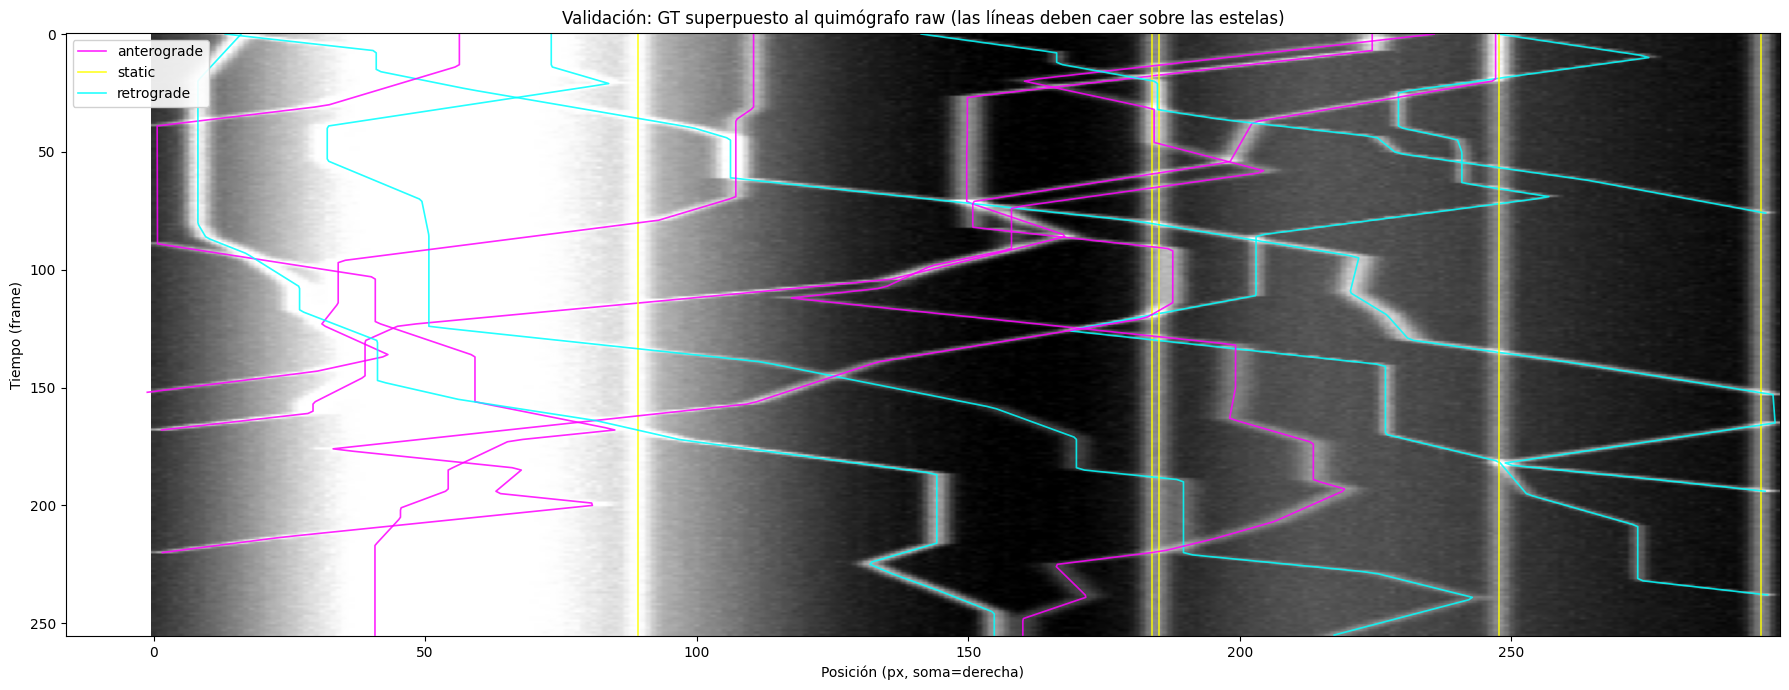

In [ ]:
# Overlay de validación: GT sobre el quimógrafo raw
# Las líneas deben caer sobre las estelas brillantes.
fig, ax = plt.subplots(figsize=(18, 7))
ax.imshow(raw, cmap="gray", aspect="auto")

COLORES_GT = {"static": "yellow", "anterograde": "magenta", "retrograde": "cyan"}
vistos = set()
for pid, sub in pos_vis.groupby("particle_id"):
    ptype = tipo_de[pid]
    sub_s = sub.sort_values("frame")
    lbl = ptype if ptype not in vistos else None
    vistos.add(ptype)
    ax.plot(
        sub_s["kymo_col"],
        sub_s["frame"],
        color=COLORES_GT.get(ptype, "white"),
        linewidth=1.2,
        alpha=0.85,
        label=lbl,
    )

ax.set_title(
    "Validación: GT superpuesto al quimógrafo raw (las líneas deben caer sobre las estelas)"
)
ax.set_xlabel("Posición (px, soma=derecha)")
ax.set_ylabel("Tiempo (frame)")
ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

---

## 7. Comparación tracks predichos vs GT


In [ ]:
THR_PX = 4.0 * scale_factor  # tolerancia de asociación, escalada al espacio de KB
MIN_OVERLAP = 10  # frames mínimos para considerar que un track "pertenece" a un GT


def gt_mas_cercano(t, x):
    mejor, dmin = -1, THR_PX
    for pid, gx in gt_por_frame.get(int(t), []):
        d = abs(x - gx)
        if d <= dmin:
            mejor, dmin = int(pid), d
    return mejor


filas = []
for k, trk in enumerate(tracks):
    etiquetas = [gt_mas_cercano(t, x) for (t, x) in trk.points]
    conteo = Counter(l for l in etiquetas if l != -1)
    sustanciales = {pid: c for pid, c in conteo.items() if c >= MIN_OVERLAP}
    dominante = (
        max(sustanciales, key=sustanciales.get)
        if sustanciales
        else (conteo.most_common(1)[0][0] if conteo else -1)
    )

    errs = [
        abs(x - gt_col[(dominante, int(t))])
        for (t, x), l in zip(trk.points, etiquetas)
        if l == dominante and dominante != -1 and (dominante, int(t)) in gt_col
    ]

    dpred = trk.points[-1][1] - trk.points[0][1]
    dir_pred = int(np.sign(dpred)) if abs(dpred) > 1 else 0

    filas.append(
        {
            "track": k,
            "gt_id": dominante,
            "gt_tipo": tipo_de.get(dominante, "-"),
            "n_puntos": len(trk.points),
            "id_switch": len(sustanciales) > 1,
            "dir_pred": dir_pred,
            "dir_gt": gt_dir.get(dominante),
            "dir_ok": (dir_pred == gt_dir.get(dominante)) if dominante != -1 else False,
            "err_px": float(np.mean(errs)) if errs else np.nan,
            "err_um": (
                float(np.mean(errs)) / scale_factor * PIXEL_SCALE if errs else np.nan
            ),
        }
    )

comp = pd.DataFrame(filas)
print(comp.to_string(index=False))

 track  gt_id     gt_tipo  n_puntos  id_switch  dir_pred  dir_gt  dir_ok   err_px   err_um
     0     14  retrograde        18      False         1       1    True 0.968785 0.103660
     1     14  retrograde        76       True         1       1    True 0.778917 0.083344
     2      1      static       249      False         0       0    True 0.166120 0.017775
     3      8 anterograde        40      False        -1      -1    True 0.430437 0.046057
     4      2      static        87      False         0       0    True 0.134819 0.014426
     5      4      static       249      False         0       0    True 0.087092 0.009319
     6      8 anterograde        76       True         1      -1   False 0.341385 0.036528
     7      0 anterograde        20      False        -1      -1    True 1.604559 0.171688
     8      2      static       248       True        -1       0   False 0.125802 0.013461
     9     10 anterograde        32      False        -1      -1    True 0.416091 0.044522

### Métricas agregadas


In [ ]:
asociados = comp[comp.gt_id != -1]
recuperadas = set(asociados.gt_id)

print("=== DETECCIÓN (recall) ===")
print(
    f"  Global: {len(recuperadas)}/{len(gt_ids)} = {100*len(recuperadas)/len(gt_ids):.0f}%"
)
for tipo in ("static", "anterograde", "retrograde"):
    ids_tipo = [p for p in gt_ids if tipo_de[p] == tipo]
    rec = len([p for p in ids_tipo if p in recuperadas])
    print(f"  {tipo:12s}: {rec}/{len(ids_tipo)}")

print("\n=== POSICIÓN ===")
err_validos = asociados.err_px.dropna()
if len(err_validos):
    # err_px está en el espacio de KB (escalado), convertir a px nativos / µm
    err_native_px = err_validos / scale_factor
    print(
        f"  Error medio  : {err_native_px.mean():.2f} px = {(err_native_px * PIXEL_SCALE).mean():.3f} µm"
    )
    print(f"  Error mediano: {err_native_px.median():.2f} px")

print("\n=== DIRECCIÓN ===")
print("  (en quimógrafo flipped: anterograde→-1 col↓, retrograde→+1 col↑)")
if len(asociados):
    print(
        f"  Acierto: {100*asociados.dir_ok.mean():.0f}% ({asociados.dir_ok.sum()}/{len(asociados)} tracks asociados)"
    )

print("\n=== CRUCES ===")
n_idswitch = int(comp.id_switch.sum())
frag = Counter(asociados.gt_id)
n_frag = sum(1 for pid, c in frag.items() if c > 1)
print(f"  ID-switches (track sobre >1 GT): {n_idswitch}/{len(tracks)} tracks")
print(f"  GTs fragmentados (>1 track):     {n_frag}/{len(recuperadas)} recuperadas")
print(f"  Tracks sin GT (falsos +):         {int((comp.gt_id == -1).sum())}")

=== DETECCIÓN (recall) ===
  Global: 13/15 = 87%
  static      : 4/5
  anterograde : 4/5
  retrograde  : 5/5

=== POSICIÓN ===
  Error medio  : 0.59 px = 0.063 µm
  Error mediano: 0.59 px

=== DIRECCIÓN ===
  (en quimógrafo flipped: anterograde→-1 col↓, retrograde→+1 col↑)
  Acierto: 77% (17/22 tracks asociados)

=== CRUCES ===
  ID-switches (track sobre >1 GT): 8/22 tracks
  GTs fragmentados (>1 track):     8/13 recuperadas
  Tracks sin GT (falsos +):         0


### GT vs predicho superpuestos


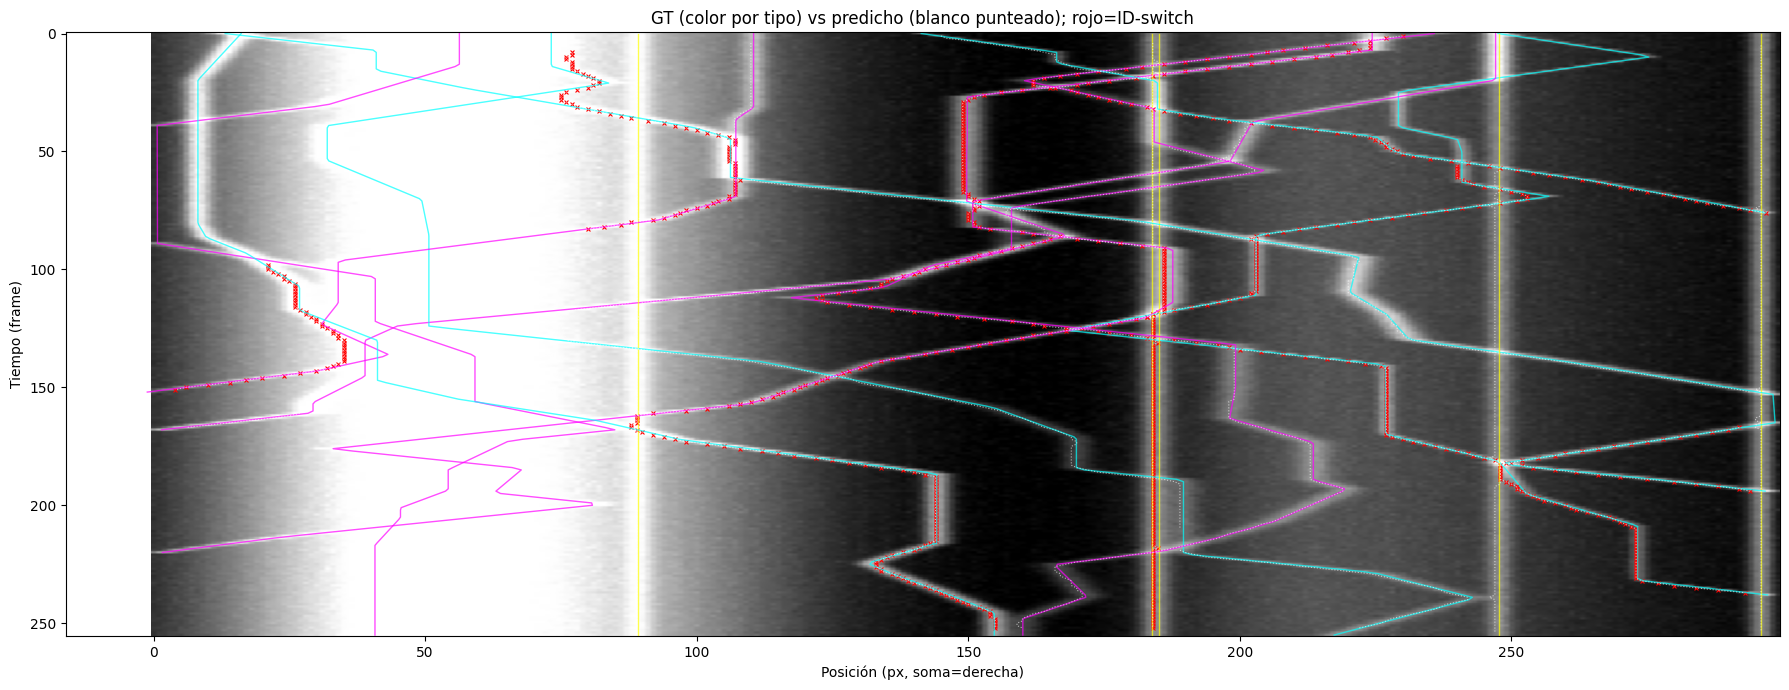

In [ ]:
fig, ax = plt.subplots(figsize=(18, 7))
ax.imshow(raw, cmap="gray", aspect="auto")

# GT — líneas finas coloreadas por tipo
COLORES_GT = {"static": "yellow", "anterograde": "magenta", "retrograde": "cyan"}
for pid, sub in pos_vis.groupby("particle_id"):
    sub_s = sub.sort_values("frame")
    ax.plot(
        sub_s["kymo_col"],
        sub_s["frame"],
        color=COLORES_GT.get(tipo_de[pid], "white"),
        linewidth=1.0,
        alpha=0.7,
    )

# Predicho — punteado blanco + rojo para ID-switches
for k, trk in enumerate(tracks):
    pts = np.array(trk.points)
    ax.plot(
        pts[:, 1], pts[:, 0], color="white", linewidth=0.8, alpha=0.6, linestyle=":"
    )
    if comp.iloc[k]["id_switch"]:
        ax.scatter(pts[:, 1], pts[:, 0], c="red", s=8, marker="x", linewidths=0.8)

ax.set_title("GT (color por tipo) vs predicho (blanco punteado); rojo=ID-switch")
ax.set_xlabel("Posición (px, soma=derecha)")
ax.set_ylabel("Tiempo (frame)")
plt.tight_layout()
plt.show()

---

## 8. (Opcional) Cinética por KymoButler


In [ ]:
from kymobutler.postprocessing import postprocess

# pixel_size_time en segundos/frame, pixel_size_space en µm/px
FPS = 2.0
stats = postprocess(
    tracks, pixel_size_time=1.0 / FPS, pixel_size_space=PIXEL_SCALE / scale_factor
)
df_cin = pd.DataFrame(stats).rename(
    columns={
        "velocity_um_per_sec": "velocidad_um_s",
        "duration_sec": "duracion_s",
        "distance_um": "distancia_um",
        "start2end_velocity_um_per_sec": "vel_neta_um_s",
    }
)

print("Distribución de dirección (postprocess de KB):")
print(f"  right (+1): {(df_cin.direction == 1).sum()}  ← retrógrado en kymo flipped")
print(f"  left  (-1): {(df_cin.direction == -1).sum()} ← anterógrado en kymo flipped")
print(f"  static( 0): {(df_cin.direction == 0).sum()}")
print()
print(
    df_cin[["direction", "velocidad_um_s", "duracion_s", "distancia_um"]]
    .describe()
    .round(3)
)

Distribución de dirección (postprocess de KB):
  right (+1): 9  ← retrógrado en kymo flipped
  left  (-1): 11 ← anterógrado en kymo flipped
  static( 0): 2

       direction  velocidad_um_s  duracion_s  distancia_um
count     22.000          22.000      22.000        22.000
mean      -0.091           0.182      48.568         8.677
std        0.971           0.058      39.207         7.807
min       -1.000           0.110       9.000         0.321
25%       -1.000           0.139      17.750         3.156
50%       -0.500           0.184      38.000         6.474
75%        1.000           0.212      56.375        12.599
max        1.000           0.371     124.500        28.783


---

## Conclusión

Medimos **KymoButler** sobre el quimógrafo sintético realista (ingenia-kymograph, nivel 1).

**Convenciones clave** para este pipeline:

- El quimógrafo está **flipped** (soma=derecha): anterógrado → col↓, retrógrado → col↑.
- El GT se convierte con `kymo_col = (W-1 - pos_um/pixel_scale) × scale_factor`.
- `scale_factor` corrige el posible redimensionado interno de KymoButler.

### Próximos pasos

1. **Nivel 2**: agregar ruido de shot (`shot.strength > 0`), iluminación no uniforme, partículas que aparecen/desaparecen — y repetir estas métricas.
2. **Promediar sobre el dataset**: iterar sobre los 10 samples del manifest y consolidar recall/error/dirección.
3. **Quimógrafos reales**: aplicar el mismo flujo de métricas a quimógrafos del laboratorio (una vez que estén anotados).
4. **Transformers**: reutilizar este harness de evaluación para comparar con modelos basados en atención.
